## 目的

一番ミニマムな形で温度解析を行います。  
一枚撮影した測温データを基に温度解析をします。

出力ファイルはtemp_up.csvとtemp_down.csvです。  
温度とフィッティング誤差のデータが出力されます。

## 準備

まず、基本的なライブラリをインポートします。

In [5]:
import sys
import os
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm

次に、測温ファイル(speファイル)を読み込むためのライブラリをインポートします。

In [6]:
from SpeReadPy.read_spe import SpeReference

## データ読み込み

生データを読み込みます。

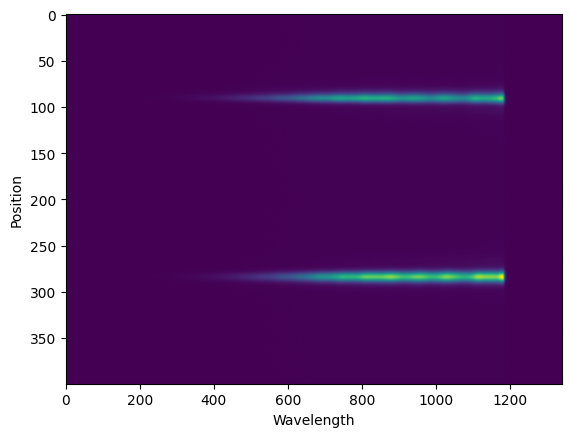

In [33]:
# 生データのパス
# (測定したデータに変更してください)
path_raw_data = r"TestData\SampleData.spe"
path_raw_data = r"D:\SPring-8-2025-Oct\Okazaki\UODE29\T2\UODE27  4.spe"

# 生データ
spe_raw_data = SpeReference(path_raw_data)

# フレーム番号
framenumber = -1

# 生データを出力
plt.imshow(spe_raw_data.get_data()[0][framenumber], aspect = "auto")
plt.xlabel("Wavelength")
plt.ylabel("Position")
plt.show()
plt.close()

校正用データを読み込みます。

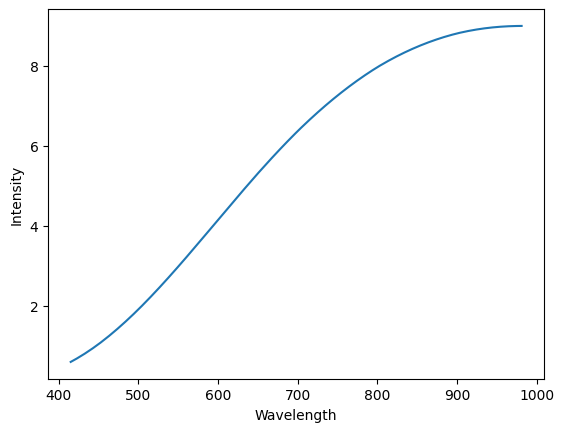

In [25]:
# リファレンスデータのパス
# SPring-8で撮影したデータを利用している以上は変更する必要はありません。
path_ref_data = r"TestData\OL245C.csv"

# リファレンスデータ
df_ref_data = pd.read_csv(
    path_ref_data,
    header = None,
    names = ["wavelength", "intensity"]
)

# 実験データの波長範囲に合うように、リファレンスデータを補間する
arr_wavelength = spe_raw_data.get_wavelengths()[0]
interp_ref_data = sp.interpolate.interp1d(df_ref_data["wavelength"], df_ref_data["intensity"])
arr_ref_data = interp_ref_data(arr_wavelength)

# データを出力する
plt.plot(arr_wavelength, arr_ref_data)
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.show()
plt.close()

フィルターデータを読み込みます。

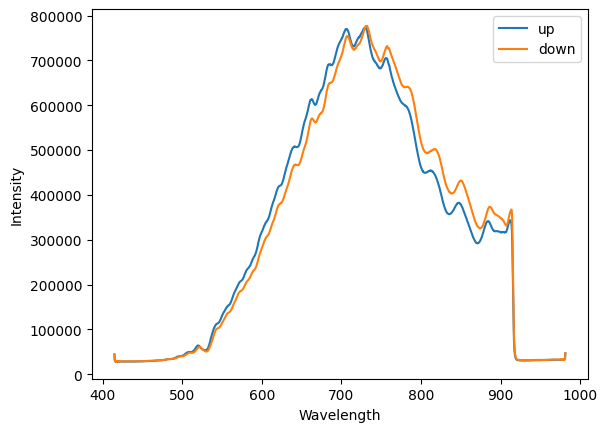

In [ ]:
# フィルターデータのパス
# フィルターデータは半期に一回変わります。
# 撮影時のフィルターデータと同じものを指定してください。
path_filter_up = r"D:\SPring-8-2025-Oct\Tcalib_BLAZE_20250910\standard\UP\0_Up_std.spe"
path_filter_down = r"D:\SPring-8-2025-Oct\Tcalib_BLAZE_20250910\standard\Down\0-Down_std.spe"

# フィルターデータ
spe_filter_up = SpeReference(path_filter_up)
spe_filter_down = SpeReference(path_filter_down)

# 出力
plt.plot(spe_filter_up.get_wavelengths()[0],spe_filter_up.get_data()[0][0,0],label = "up")
plt.plot(spe_filter_down.get_wavelengths()[0],spe_filter_down.get_data()[0][0,0], label = "down")
plt.legend()
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.show()
plt.close()

## データ校正

### 上流

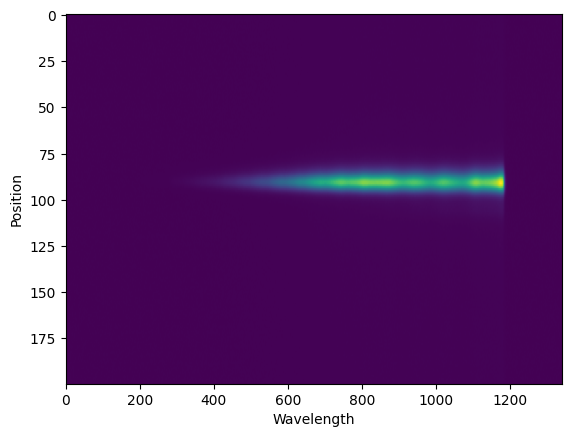

In [34]:
# 上流のデータがポジションとしてどの位置にあるのかを指定します。
pos_range_up = (0,200)

# 上流のデータを取り出す
arr_raw_up = spe_raw_data.get_data()[0][framenumber,pos_range_up[0]:pos_range_up[1]]

# 出力
plt.imshow(arr_raw_up, aspect = "auto")
plt.xlabel("Wavelength")
plt.ylabel("Position")
plt.show()
plt.close()

サンプルからの輻射を計算します

In [36]:
arr_sample_up = arr_ref_data * arr_raw_up / spe_filter_up.get_data()[0][framenumber,0]

### 下流

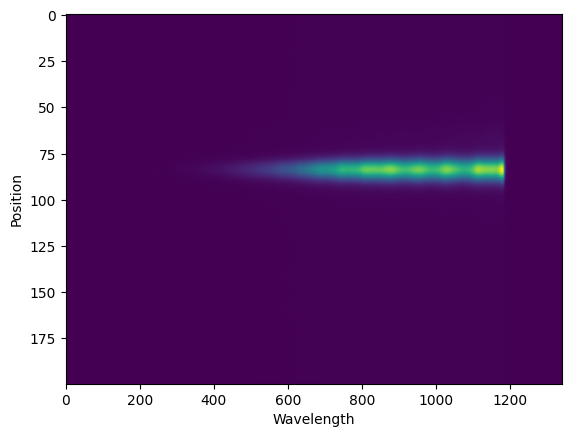

In [37]:
# 上流のデータがポジションとしてどの位置にあるのかを指定します。
pos_range_down = (200,400)

# 上流のデータを取り出す
arr_raw_down = spe_raw_data.get_data()[0][framenumber,pos_range_down[0]:pos_range_down[1]]

# 出力
plt.imshow(arr_raw_down, aspect = "auto")
plt.xlabel("Wavelength")
plt.ylabel("Position")
plt.show()
plt.close()

サンプルからの輻射を計算します

In [38]:
arr_sample_down = arr_ref_data * arr_raw_down / spe_filter_down.get_data()[0][framenumber,0]

## 温度計算

### 上流

まず温度計算をする領域を、各ピクセルごとにすべての波長の強度を合計強度比から決めます。

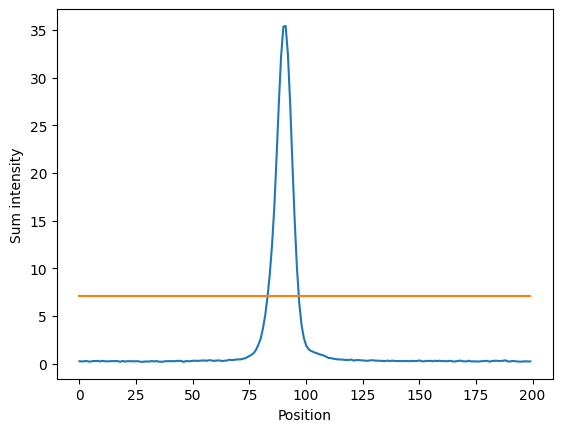

In [39]:
# 各ピクセル強度比の閾値です。
# これ以上の強度を持つ位置の輻射スペクトルが計算されます。
intensity_threshold = 0.2

# 強度の合計を計算
arr_sample_up_sum = arr_sample_up.sum(axis = 1)

# 強度の最大値を計算
max_intensity_up = arr_sample_up_sum.max()

# 強度マスクを計算
arr_intensity_mask_up = (arr_sample_up_sum > max_intensity_up * intensity_threshold)

# 横軸を計算
arr_pos_up = np.arange(*pos_range_up)

# 出力
plt.plot(arr_pos_up,arr_sample_up.sum(axis = 1))
plt.plot([arr_pos_up[0], arr_pos_up[-1]], [max_intensity_up*intensity_threshold]*2)
plt.xlabel("Position")
plt.ylabel("Sum intensity")
plt.show()

各ポジションに対して温度計算を行います。

200it [00:00, 9541.83it/s]


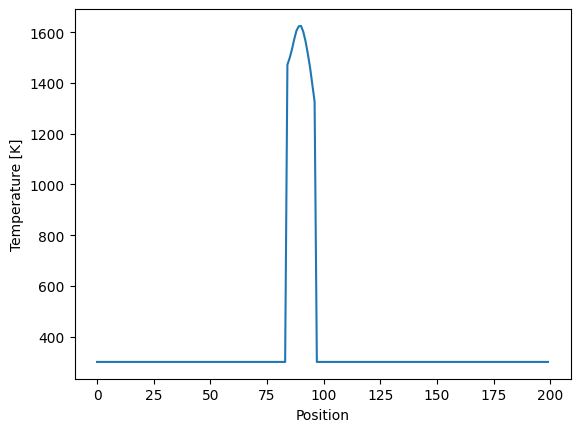

In [47]:
# プランク関数の定義
def planck_function(wavelength, T, A):
    """
    wavelength: 波長 (nm単位), T: 温度 (K), A: スケール因子
    """
    h = sp.constants.h
    c = sp.constants.c
    k = sp.constants.k    
    wavelength_m = wavelength * 1e-9  # nm -> m
    intensity = (2 * h * c**2) / (wavelength_m**5) * (1 / (np.exp((h * c) / (wavelength_m * k * T)) - 1))
    return A * intensity

# 計算を行う波長範囲
wavelength_range = (600, 800)
arr_wavelength_mask = (arr_wavelength > 600) & (arr_wavelength < 800)
arr_wavelength_fit = arr_wavelength[arr_wavelength_mask]

# フィッティング用の初期値
initial_temperature = 3000  # 初期温度を 3000 K に設定
initial_scale = 1e-6        # 初期スケール因子を適当に設定

# フィッティング計算の格納リスト
l_temperature_up = []
l_err_up = []

# 各ポジションに対して計算
for i, p in tqdm(enumerate(range(*pos_range_up))):

    # 強度が十分な場合フィッティングを行う
    if arr_intensity_mask_up[i]:
        arr_sample_up_fit = arr_sample_up[i][arr_wavelength_mask]
        popt, pcov = sp.optimize.curve_fit(
            planck_function,
            arr_wavelength_fit,
            arr_sample_up_fit,
            p0 = [
                initial_temperature,
                initial_scale
            ]
        )
        fitted_temperature, fitted_scale = popt
        temperature_err, scale_err = np.sqrt(np.diag(pcov))
        l_temperature_up.append(fitted_temperature)
        l_err_up.append(temperature_err)

    # 強度が十分でない場合フィッティングを行わない
    else:
        l_temperature_up.append(300)
        l_err_up.append(0)

# 出力
plt.plot(arr_pos_up, l_temperature_up)
plt.xlabel("Position")
plt.ylabel("Temperature [K]")
plt.show()

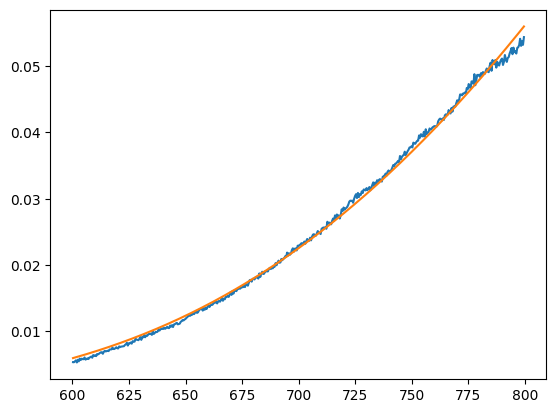

In [54]:
arr_sample_up_fit = arr_sample_up[90][arr_wavelength_mask]
plt.plot(arr_wavelength_fit, arr_sample_up_fit)
popt, pcov = sp.optimize.curve_fit(
    planck_function,
    arr_wavelength_fit,
    arr_sample_up_fit,
    p0 = [
        initial_temperature,
        initial_scale
    ]
)
plt.plot(arr_wavelength_fit,planck_function(arr_wavelength_fit,*popt))

In [56]:
spe_dist_data = SpeReference(r"D:\SPring-8-2025-Oct\Okazaki\UODE29\T2\UODE27  4_dist.spe")
arr_dist_data = spe_dist_data.get_data()[0]

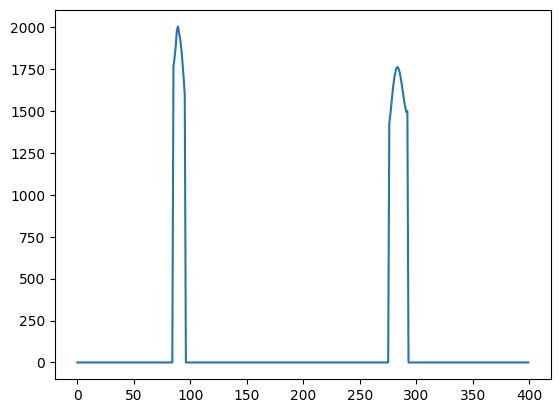

In [58]:
plt.plot(arr_dist_data[0,-1])

計算結果をcsvで出力します。

In [41]:
csvfile_up = "temp_up.csv"
pd.DataFrame(
    data = {
        "Position": arr_pos_up,
        "Temperature [K]": l_temperature_up,
        "Error [K]": l_err_up,
    }
).to_csv(csvfile_up)

### 下流

まず温度計算をする領域を、各ピクセルごとにすべての波長の強度を合計強度比から決めます。

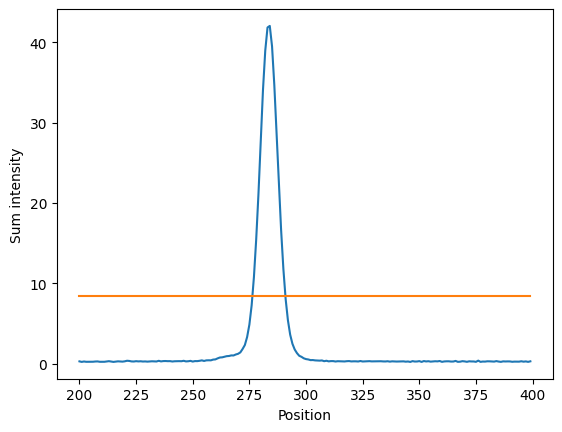

In [42]:
# 各ピクセル強度比の閾値です。
# これ以上の強度を持つ位置の輻射スペクトルが計算されます。
intensity_threshold = 0.2

# 強度の合計を計算
arr_sample_down_sum = arr_sample_down.sum(axis = 1)

# 強度の最大値を計算
max_intensity_down = arr_sample_down_sum.max()

# 強度マスクを計算
arr_intensity_mask_down = (arr_sample_down_sum > max_intensity_down * intensity_threshold)

# 横軸を計算
arr_pos_down = np.arange(*pos_range_down)

# 出力
plt.plot(arr_pos_down,arr_sample_down.sum(axis = 1))
plt.plot([arr_pos_down[0], arr_pos_down[-1]], [max_intensity_down*intensity_threshold]*2)
plt.xlabel("Position")
plt.ylabel("Sum intensity")
plt.show()

各ポジションに対して温度計算を行います。

200it [00:00, 9780.12it/s]


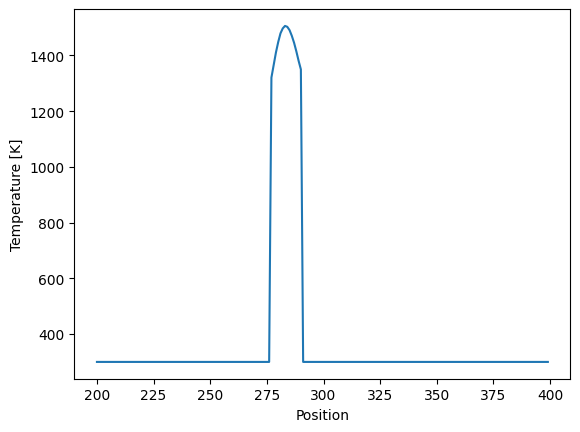

In [43]:
# プランク関数の定義
def planck_function(wavelength, T, A):
    """
    wavelength: 波長 (nm単位), T: 温度 (K), A: スケール因子
    """
    h = sp.constants.h
    c = sp.constants.c
    k = sp.constants.k    
    wavelength_m = wavelength * 1e-9  # nm -> m
    intensity = (2 * h * c**2) / (wavelength_m**5) * (1 / (np.exp((h * c) / (wavelength_m * k * T)) - 1))
    return A * intensity

# 計算を行う波長範囲
wavelength_range = (600, 800)
arr_wavelength_mask = (arr_wavelength > 600) & (arr_wavelength < 800)
arr_wavelength_fit = arr_wavelength[arr_wavelength_mask]

# フィッティング用の初期値
initial_temperature = 3000  # 初期温度を 3000 K に設定
initial_scale = 1e-6        # 初期スケール因子を適当に設定

# フィッティング計算の格納リスト
l_temperature_down = []
l_err_down = []

# 各ポジションに対して計算
for i, p in tqdm(enumerate(range(*pos_range_down))):

    # 強度が十分な場合フィッティングを行う
    if arr_intensity_mask_down[i]:
        arr_sample_down_fit = arr_sample_down[i][arr_wavelength_mask]
        popt, pcov = sp.optimize.curve_fit(
            planck_function,
            arr_wavelength_fit,
            arr_sample_down_fit,
            p0 = [
                initial_temperature,
                initial_scale
            ]
        )
        fitted_temperature, fitted_scale = popt
        temperature_err, scale_err = np.sqrt(np.diag(pcov))
        l_temperature_down.append(fitted_temperature)
        l_err_down.append(temperature_err)

    # 強度が十分でない場合フィッティングを行わない
    else:
        l_temperature_down.append(300)
        l_err_down.append(0)

# 出力
plt.plot(arr_pos_down, l_temperature_down)
plt.xlabel("Position")
plt.ylabel("Temperature [K]")
plt.show()

計算結果をcsvで出力します。

In [44]:
csvfile_down = "temp_down.csv"
pd.DataFrame(
    data = {
        "Position": arr_pos_down,
        "Temperature [K]": l_temperature_down,
        "Error [K]": l_err_down,
    }
).to_csv(csvfile_down)